# Predicting F1 Pit Stops

In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

## Data Read

In [2]:
# Kaggle Notebook
# df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
# df_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')

# local 
data_path = "/mnt/e/Kaggle_Competitions/Predicting_F1_Pit_Stops"
train_dp = os.path.join(data_path, "train.csv")
test_dp = os.path.join(data_path, "test.csv")

df_train = pd.read_csv(train_dp)
df_test = pd.read_csv(test_dp)

In [3]:
# df_train.head()

In [4]:
df_train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

## Data Preprocessing and Analysis

### One-Hot Encoding

In [6]:
# Dropout Columns
drop_cols = ['id', 'Driver', 'Race']
df_train_drop = df_train.drop(columns=drop_cols).copy()
df_test_drop = df_test.drop(columns=drop_cols).copy()

# One-Hot Encoding
encoding_cols = ['Compound']
df_train_encoded = pd.get_dummies(df_train_drop, columns=encoding_cols)
df_test_encoded = pd.get_dummies(df_test_drop, columns=encoding_cols)

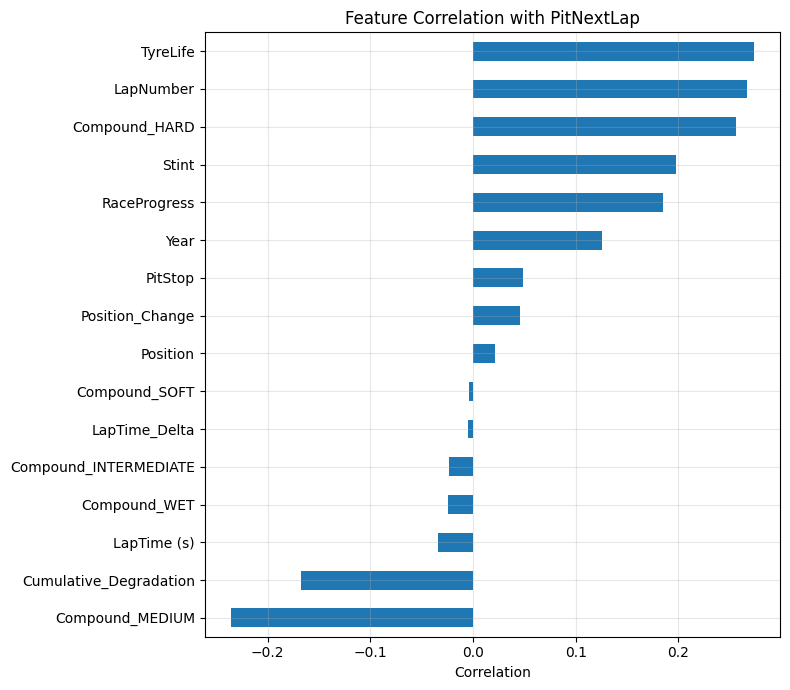

In [7]:
corr = df_train_encoded.corrwith(df_train_encoded['PitNextLap']).sort_values(ascending=False)

# print(corr)

plt.figure(figsize=(8, 7))
corr.drop('PitNextLap').head(30).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Correlation with PitNextLap')
plt.xlabel('Correlation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Engineering

In [8]:
df_train_fe = df_train_encoded.copy()
df_test_fe = df_test_encoded.copy()

df_train_fe['TyreLapInteraction'] = (df_train_fe['TyreLife'] * df_train_fe['LapNumber'])
df_test_fe['TyreLapInteraction'] = (df_test_fe['TyreLife'] * df_test_fe['LapNumber'])

if 'Compound_HARD' in df_train_fe.columns:
    df_train_fe['HardLife'] = (df_train_fe['Compound_HARD'] * df_train_fe['TyreLife'])
    df_test_fe['HardLife'] = (df_test_fe['Compound_HARD'] * df_test_fe['TyreLife'])

df_train_fe['HardLapInteraction'] = (df_train_fe['Compound_HARD'] * df_train_fe['LapNumber'])
df_test_fe['HardLapInteraction'] = (df_test_fe['Compound_HARD'] * df_test_fe['LapNumber'])

df_train_fe['TyreProgressInteraction'] = (df_train_fe['TyreLife'] * df_train_fe['RaceProgress'])
df_test_fe['TyreProgressInteraction'] = (df_test_fe['TyreLife'] * df_test_fe['RaceProgress'])

df_train_fe['HardProgressInteraction'] = (df_train_fe['Compound_HARD'] * df_train_fe['RaceProgress'])
df_test_fe['HardProgressInteraction'] = (df_test_fe['Compound_HARD'] * df_test_fe['RaceProgress'])

df_train_fe['StintTyreInteraction'] = (df_train_fe['Stint'] * df_train_fe['TyreLife'])
df_test_fe['StintTyreInteraction'] = (df_test_fe['Stint'] * df_test_fe['TyreLife'])

df_train_fe['PositionTyreInteraction'] = (df_train_fe['Position'] * df_train_fe['TyreLife'])
df_test_fe['PositionTyreInteraction'] = (df_test_fe['Position'] * df_test_fe['TyreLife'])

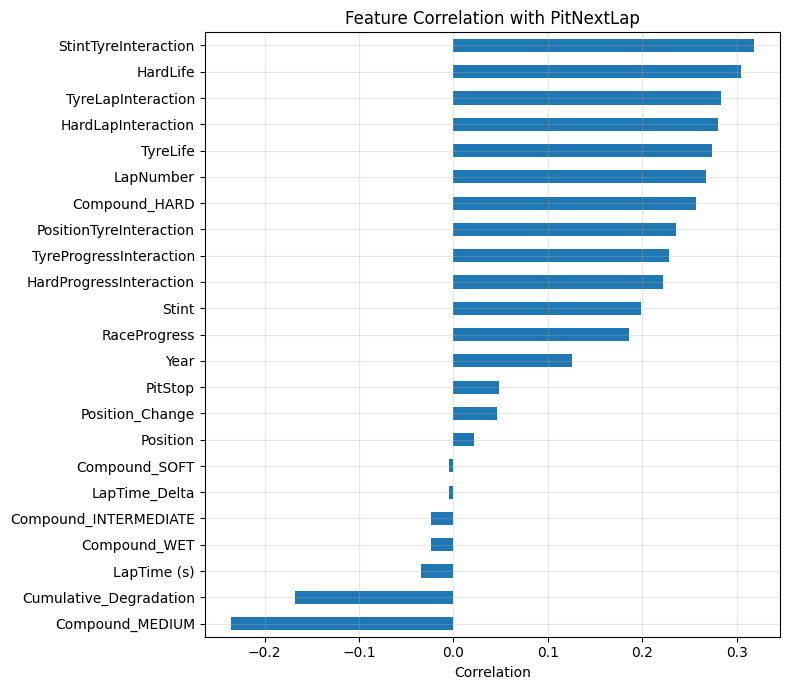

In [9]:
corr = df_train_fe.corrwith(df_train_fe['PitNextLap']).sort_values(ascending=False)

# print(corr)

plt.figure(figsize=(8, 7))
corr.drop('PitNextLap').head(30).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Correlation with PitNextLap')
plt.xlabel('Correlation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model Train and Test

### Training Setup

In [10]:
# train_ and test_ dataset processing
TARGET = 'PitNextLap'
dset_train = df_train_fe.copy()
X = dset_train.drop(columns=[TARGET])
y = dset_train[TARGET]
X_test = df_test_fe.copy()

X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

In [11]:
# training and test setup
n_splits = 3
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

### Random Forest Model

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_preds = np.zeros(len(X_test))
rf_valid_auc = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    # Random Forest
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=30,
        min_samples_leaf=10,
        min_samples_split=5,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42,
        class_weight='balanced'
    )

    # train
    model.fit(X_train, y_train)

    # valid
    train_pred = model.predict_proba(X_train)[:,1]
    valid_pred = model.predict_proba(X_valid)[:,1]

    train_auc = roc_auc_score(y_train, train_pred)
    valid_auc = roc_auc_score(y_valid, valid_pred)

    rf_valid_auc.append(valid_auc)

    print(f'Fold {fold + 1}: Train AUC = {train_auc:.5f}, Valid AUC = {valid_auc:.5f}')

    # test
    rf_preds += model.predict_proba(X_test)[:,1] / n_splits

Fold 1: Train AUC = 0.96955, Valid AUC = 0.93885
Fold 2: Train AUC = 0.96976, Valid AUC = 0.93779
Fold 3: Train AUC = 0.96968, Valid AUC = 0.93811


### LightGBM Model

In [13]:
import lightgbm as lgb

lgb_preds = np.zeros(len(X_test))

lgb_valid_auc = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = lgb.LGBMClassifier(
        n_estimators=5000,
        learning_rate=0.01,
        num_leaves=32,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=2,
        reg_lambda=3,
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train, y_train, eval_set=[(X_valid,y_valid)], 
        callbacks=[lgb.early_stopping(100)]
    )

    train_pred = model.predict_proba(X_train)[:,1]
    valid_pred = model.predict_proba(X_valid)[:,1]

    train_auc = roc_auc_score(y_train, train_pred)
    valid_auc = roc_auc_score(y_valid, valid_pred)

    lgb_valid_auc.append(valid_auc)

    print(f'Fold {fold+1}: Train AUC={train_auc:.5f}, Valid AUC={valid_auc:.5f}')

    lgb_preds += model.predict_proba(X_test)[:,1] / n_splits

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[4996]	valid_0's binary_logloss: 0.235835
Fold 1: Train AUC=0.95428, Valid AUC=0.94422
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's binary_logloss: 0.237646
Fold 2: Train AUC=0.95440, Valid AUC=0.94315
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[4998]	valid_0's binary_logloss: 0.236772
Fold 3: Train AUC=0.95443, Valid AUC=0.94363


## Test Result

In [14]:
rf_valid_auc_mean = np.mean(rf_valid_auc)
lgb_valid_auc_mean = np.mean(lgb_valid_auc)

rf_weight = rf_valid_auc_mean / (rf_valid_auc_mean + lgb_valid_auc_mean)
lgb_weight = lgb_valid_auc_mean / (rf_valid_auc_mean + lgb_valid_auc_mean)

final_preds = rf_weight * rf_preds + lgb_weight * lgb_preds

submission = pd.DataFrame({
    'id': df_test['id'],
    'PitNextLap': final_preds
})

preds_save_path = os.path.join(data_path, 'submission.csv')
submission.to_csv(preds_save_path, index=False)